In [22]:
import threading
from collections import Counter
from typing import Dict, List, Tuple
import time
import os

class TextProcessor:
    def __init__(self, file_path: str, chunk_size: int = 1024 * 1024):
        self.file_path = file_path
        self.chunk_size = chunk_size
        self.word_count = 0
        self.word_freq = Counter()
        self.lock = threading.Lock()

    def process_chunk(self, chunk: str) -> Tuple[int, Counter]:
        """Process a chunk of text and return word count and frequency."""
        words = chunk.split()
        return len(words), Counter(words)

    def process_file_chunk(self, start_pos: int, end_pos: int):
        """Process a specific portion of the file."""
        with open(self.file_path, 'r', encoding='utf-8') as file:
            file.seek(start_pos)
            chunk = file.read(end_pos - start_pos)
            word_count, word_freq = self.process_chunk(chunk)
            
            with self.lock:
                self.word_count += word_count
                self.word_freq.update(word_freq)

    def get_file_size(self) -> int:
        """Get the total size of the file."""
        with open(self.file_path, 'r', encoding='utf-8') as file:
            file.seek(0, 2)  # Seek to end of file
            return file.tell()

    def process_file(self, num_threads: int = 4) -> Tuple[int, Dict[str, int]]:
        """Process the file using multiple threads."""
        file_size = self.get_file_size()
        chunk_size = file_size // num_threads
        
        threads = []
        for i in range(num_threads):
            start_pos = i * chunk_size
            end_pos = start_pos + chunk_size if i < num_threads - 1 else file_size
            
            thread = threading.Thread(
                target=self.process_file_chunk,
                args=(start_pos, end_pos)
            )
            threads.append(thread)
            thread.start()

        for thread in threads:
            thread.join()

        return self.word_count, dict(self.word_freq)

In [23]:
def main():
    
    # Get the relative path to the text8 file
    file_path = os.path.join('..', 'data', 'text8')

    # Initialize the processor
    processor = TextProcessor(file_path)
    
    # Process the file and measure time
    start_time = time.time()
    total_words, word_freq = processor.process_file()
    end_time = time.time()
    
    # Print results
    print(f"Total number of words: {total_words}")
    print(f"Number of unique words: {len(word_freq)}")
    print(f"Processing time: {end_time - start_time:.2f} seconds")
    
    # Print top 10 most frequent words
    print("\nTop 10 most frequent words:")
    for word, freq in sorted(word_freq.items(), key=lambda x: x[1], reverse=True)[:10]:
        print(f"{word}: {freq}")
    
    return total_words, word_freq


main() 

Total number of words: 17005210
Number of unique words: 253857
Processing time: 2.97 seconds

Top 10 most frequent words:
the: 1061396
of: 593677
and: 416629
one: 411764
in: 372201
a: 325873
to: 316376
zero: 264975
nine: 250430
two: 192644


(17005210,
 {'anarchism': 303,
  'originated': 572,
  'as': 131815,
  'a': 325873,
  'term': 7219,
  'of': 593677,
  'abuse': 563,
  'first': 28810,
  'used': 22737,
  'against': 8432,
  'early': 10172,
  'working': 2271,
  'class': 3412,
  'radicals': 116,
  'including': 9633,
  'the': 1061396,
  'diggers': 25,
  'english': 11868,
  'revolution': 2029,
  'and': 416629,
  'sans': 68,
  'culottes': 6,
  'french': 8736,
  'whilst': 481,
  'is': 183153,
  'still': 7378,
  'in': 372201,
  'pejorative': 114,
  'way': 6433,
  'to': 316376,
  'describe': 1352,
  'any': 11803,
  'act': 3502,
  'that': 109510,
  'violent': 653,
  'means': 4165,
  'destroy': 466,
  'organization': 2374,
  'society': 4067,
  'it': 73334,
  'has': 37866,
  'also': 44358,
  'been': 25383,
  'taken': 3043,
  'up': 12445,
  'positive': 1254,
  'label': 646,
  'by': 111831,
  'self': 2879,
  'defined': 2449,
  'anarchists': 203,
  'word': 5678,
  'derived': 1701,
  'from': 72871,
  'greek': 4577,
  'without': 5661,
  

Total number of words: 17005210
Number of unique words: 253857
Processing time: 2.89 seconds

Top 10 most frequent words:
the: 1061396
of: 593677
and: 416629
one: 411764
in: 372201
a: 325873
to: 316376
zero: 264975
nine: 250430
two: 192644


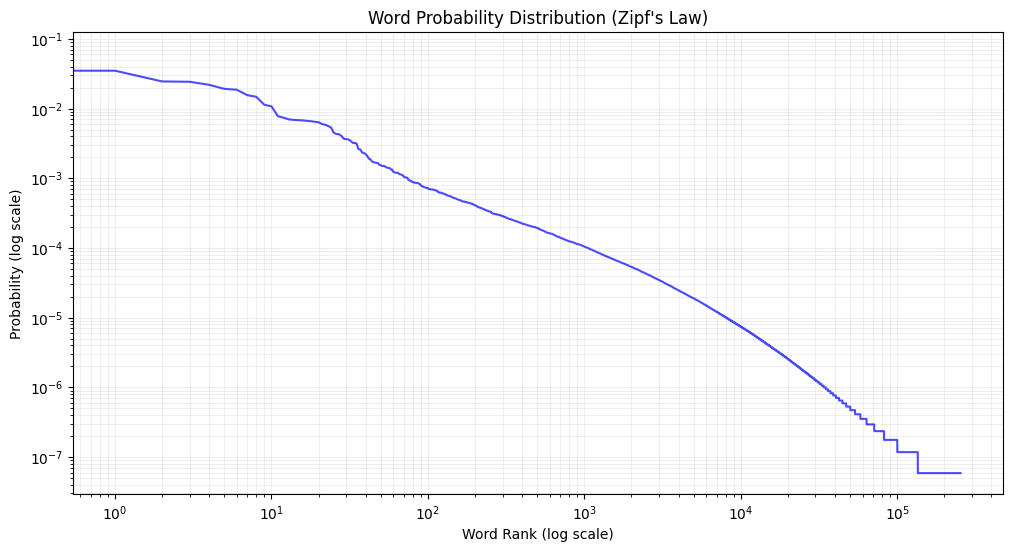


Top 25 words and their probabilities:
the: 0.062416
of: 0.034911
and: 0.024500
one: 0.024214
in: 0.021887
a: 0.019163
to: 0.018605
zero: 0.015582
nine: 0.014727
two: 0.011329
is: 0.010770
as: 0.007751
eight: 0.007367
for: 0.006965
s: 0.006863
five: 0.006809
three: 0.006749
was: 0.006634
by: 0.006576
that: 0.006440
four: 0.006362
six: 0.006007
seven: 0.005862
with: 0.005622
on: 0.005366

Bottom 25 words and their probabilities:
sankranthy: 0.000000
talikota: 0.000000
carlowitz: 0.000000
dogali: 0.000000
poorna: 0.000000
ampezzo: 0.000000
chrestien: 0.000000
ristenpart: 0.000000
ancel: 0.000000
feiffer: 0.000000
coxsone: 0.000000
saidu: 0.000000
momoh: 0.000000
ruggeri: 0.000000
ridgeley: 0.000000
gimelstob: 0.000000
heafy: 0.000000
japenese: 0.000000
chavarria: 0.000000
khevenh: 0.000000
schultens: 0.000000
yvor: 0.000000
sauv: 0.000000
brodkey: 0.000000
aliwal: 0.000000


In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Get the word frequencies
total_words, word_freq = main()

# Calculate probabilities
word_probs = {word: freq/total_words for word, freq in word_freq.items()}

# Sort words by probability
sorted_probs = sorted(word_probs.items(), key=lambda x: x[1], reverse=True)

# Create the plot
plt.figure(figsize=(12, 6))

# Plot the probability distribution
probabilities = [prob for _, prob in sorted_probs]
plt.plot(range(len(probabilities)), probabilities, 'b-', alpha=0.7)
plt.xscale('log')
plt.yscale('log')

# Add labels and title
plt.xlabel('Word Rank (log scale)')
plt.ylabel('Probability (log scale)')
plt.title('Word Probability Distribution (Zipf\'s Law)')

# Add grid
plt.grid(True, which="both", ls="-", alpha=0.2)

# Show the plot
plt.show()

# Print some statistics
print(f"\nTop 25 words and their probabilities:")
for word, prob in sorted_probs[:25]:
    print(f"{word}: {prob:.6f}")

print(f"\nBottom 25 words and their probabilities:")
for word, prob in sorted_probs[-25:]:
    print(f"{word}: {prob:.6f}")

This visualization will show:
A log-log plot of word probabilities, which should follow Zipf's Law (a power law distribution)
The x-axis shows word rank (1st most frequent, 2nd most frequent, etc.)
The y-axis shows the probability of each word
Both axes are on a logarithmic scale to better show the distribution
Additional statistics showing the top and bottom 5 words with their exact probabilities
The plot should show a roughly straight line on the log-log scale, which is characteristic of Zipf's Law in natural language. This law states that the frequency of any word is inversely proportional to its rank in the frequency table.